# Classification using Logistic Regression

Building a classification model using Logistic Regression and comparing it with other models such as Decision Tree, Random Forest, and SVM.

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()

Saving 1) iris.csv to 1) iris.csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Data Preprocessing

Preparing the dataset for machine learning by:
- Encoding the target variable (species)
- Splitting features and labels
- Checking data balance

In [ ]:
import pandas as pd

X = df.drop('species', axis=1)
y = df['species']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Feature shape: (150, 4)
Target shape: (150,)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Label Encoding

Converting the categorical target variable (species) into numerical values so that machine learning models can process it.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class Mapping:")
for i, class_name in enumerate(le.classes_):
    print(class_name, "->", i)

y_encoded[:10]

Class Mapping:
setosa -> 0
versicolor -> 1
virginica -> 2


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Train-Test Split and Feature Scaling

In this step is to split the dataset into training and testing sets (80/20). Feature scaling is applied using StandardScaler to improve model performance, especially for Logistic Regression and SVM.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (120, 4)
Test shape: (30, 4)


## Logistic Regression Model

We train a Logistic Regression classifier to predict the species of the Iris. The model is evaluated using accuracy, precision, recall, and ROC curve analysis.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log, average='weighted')
rec_log = recall_score(y_test, y_pred_log, average='weighted')

print("Logistic Regression Results")
print("Accuracy:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))

Logistic Regression Results
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Decision Tree Classifier

Training a Decision Tree model to compare its performance with Logistic Regression. Decision Trees capture non linear relationships in data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Results")
print("Accuracy:", acc_dt)
print("Precision:", prec_dt)
print("Recall:", rec_dt)

Decision Tree Results
Accuracy: 0.9
Precision: 0.9023569023569024
Recall: 0.9


## Random Forest Classifier

Combining multiple decision trees to improve accuracy and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)

Random Forest Results
Accuracy: 0.9
Precision: 0.9023569023569024
Recall: 0.9


## Support Vector Machine (SVM)

Next step is to find the optimal boundary hyperplane between classes, especially effective in small datasets like Iris.

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test, y_pred_svm, average='weighted')

print("SVM Results")
print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)

SVM Results
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667


## ROC Curve Analysis

Plotting the ROC curves for all classes using the One vs Rest approach to evaluate model performance across all classes.

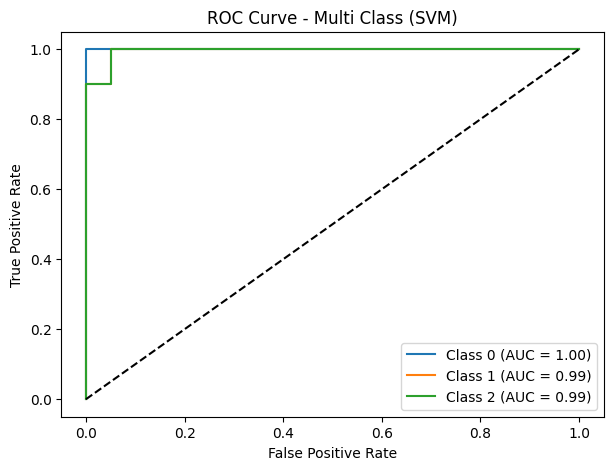

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

y_score = svm_model.predict_proba(X_test_scaled)

plt.figure(figsize=(7,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Multi Class (SVM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Final Model Comparison

This table summarizes the performance of all classification models used in the study.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [acc_log, acc_dt, acc_rf, acc_svm],
    "Precision": [prec_log, prec_dt, prec_rf, prec_svm],
    "Recall": [rec_log, rec_dt, rec_rf, rec_svm]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,Decision Tree,0.900000,0.902357,0.900000
2,Random Forest,0.900000,0.902357,0.900000
3,SVM,0.966667,0.969697,0.966667


## Conclusion

- Logistic Regression achieved strong baseline performance (93% accuracy).
- Decision Tree and Random Forest performed similarly (90% accuracy).
- SVM achieved the best performance with approximately 96.7% accuracy.

### Final Insight:
SVM is the most effective model for this dataset due to its ability to create optimal decision boundaries between classes.